# Debugging and Testing Embedding Computation Script

This notebook is designed to test and debug the embedding computation script. It performs the following steps:

1. Compute embeddings for 10 frames.
2. Store and print the embeddings and their paths for verification.
3. Run YOLO on the frames to detect objects belonging to the classes 'person', 'car', and 'building'.
4. Crop the detected objects and display the cropped images for verification.

In [8]:
# Import Required Libraries
import os
import pickle
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Ensure the required directories exist
FRAMES_DIR = Path("app/output_frames")
CROPPED_DIR = Path("app/cropped_objects")

# Classes to detect
YOLO_CLASSES = ['person', 'building', 'car']

In [17]:
# Compute embeddings for 10 frames
frame_paths = sorted(FRAMES_DIR.rglob("*.jpg"))[50:60]  # Search recursively for .jpg files
embeddings = {}

for frame_path in frame_paths:
    # Simulate embedding computation (replace with actual model call)
    embeddings[frame_path.name] = np.random.rand(512)  # Example: 512-dim embedding

print("Computed Embeddings:")
for path, emb in embeddings.items():
    print(f"{path}: {emb[:5]}...")  # Print first 5 values for brevity

Computed Embeddings:
video_1_frame_00051.jpg: [0.63912945 0.15305878 0.30393506 0.29518259 0.09057568]...
video_1_frame_00052.jpg: [0.19258052 0.81044212 0.71488519 0.21899194 0.87745422]...
video_1_frame_00053.jpg: [0.98956156 0.63795944 0.91299222 0.98836245 0.25517465]...
video_1_frame_00054.jpg: [0.95656419 0.97746445 0.72104993 0.52468284 0.30798869]...
video_1_frame_00055.jpg: [0.80584508 0.40231172 0.39622464 0.24576887 0.23878246]...
video_1_frame_00056.jpg: [0.46621476 0.56564461 0.80756258 0.95585896 0.03254491]...
video_1_frame_00057.jpg: [0.85614194 0.37831989 0.7253213  0.87555169 0.04504599]...
video_1_frame_00058.jpg: [0.66804877 0.7804987  0.44704948 0.71246395 0.38820622]...
video_1_frame_00059.jpg: [0.43857307 0.22479344 0.74450261 0.197771   0.93795211]...
video_1_frame_00060.jpg: [0.67572668 0.39353778 0.74727771 0.50393135 0.64513861]...


In [18]:
# Store and print embeddings and paths
with open("frame_paths.pkl", "wb") as f:
    pickle.dump(list(embeddings.keys()), f)

print("Stored Frame Paths:")
print(list(embeddings.keys()))

Stored Frame Paths:
['video_1_frame_00051.jpg', 'video_1_frame_00052.jpg', 'video_1_frame_00053.jpg', 'video_1_frame_00054.jpg', 'video_1_frame_00055.jpg', 'video_1_frame_00056.jpg', 'video_1_frame_00057.jpg', 'video_1_frame_00058.jpg', 'video_1_frame_00059.jpg', 'video_1_frame_00060.jpg']


Checking what frame files actually exist:
Found 10 frame files:
  1. app/output_frames/video_1/video_1_frame_00001.jpg
  2. app/output_frames/video_1/video_1_frame_00002.jpg
  3. app/output_frames/video_1/video_1_frame_00003.jpg
  4. app/output_frames/video_1/video_1_frame_00004.jpg
  5. app/output_frames/video_1/video_1_frame_00005.jpg
  6. app/output_frames/video_1/video_1_frame_00006.jpg
  7. app/output_frames/video_1/video_1_frame_00007.jpg
  8. app/output_frames/video_1/video_1_frame_00008.jpg
  9. app/output_frames/video_1/video_1_frame_00009.jpg
  10. app/output_frames/video_1/video_1_frame_00010.jpg
Processing: app/output_frames/video_1/video_1_frame_00001.jpg
  -> Found 1 objects
Processing: app/output_frames/video_1/video_1_frame_00002.jpg
  -> Found 1 objects
Processing: app/output_frames/video_1/video_1_frame_00002.jpg
  -> Found 1 objects
Processing: app/output_frames/video_1/video_1_frame_00003.jpg
  -> Found 1 objects
Processing: app/output_frames/video_1/video_1_frame_0

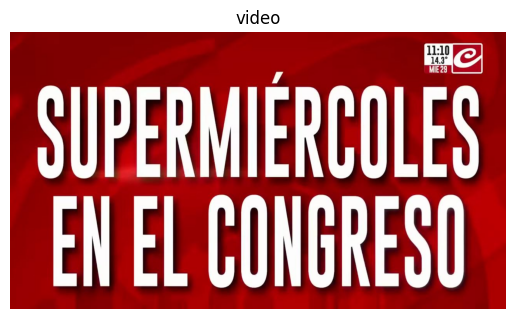

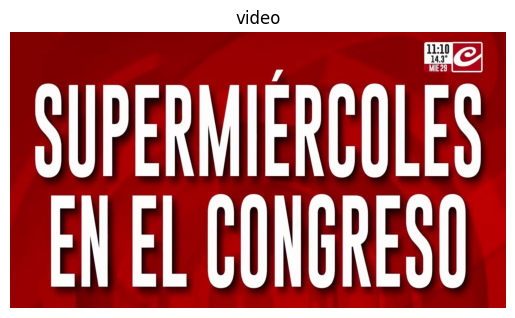

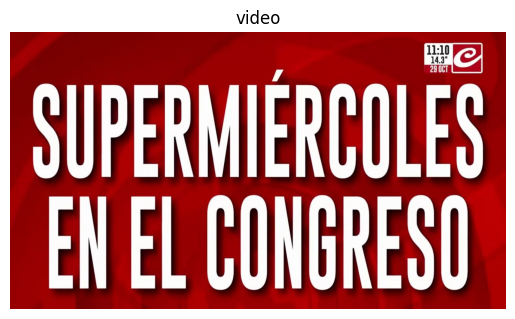

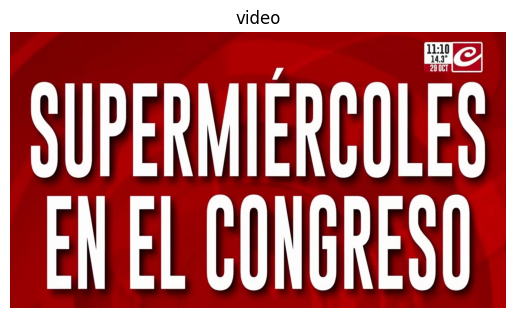

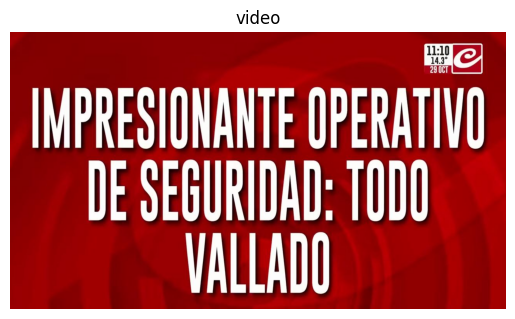

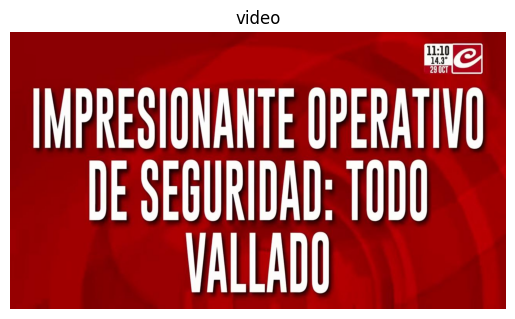

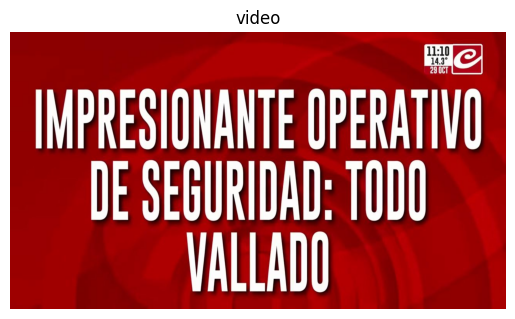

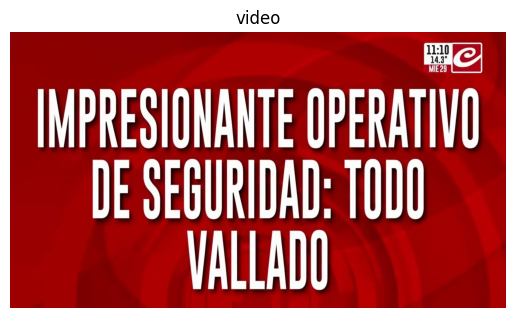

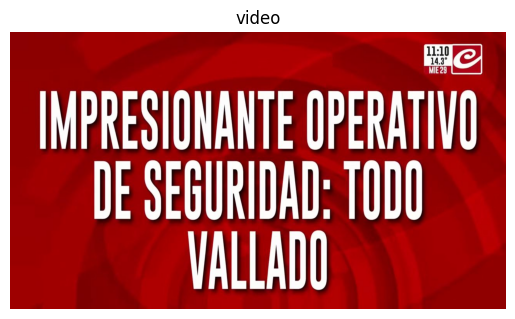

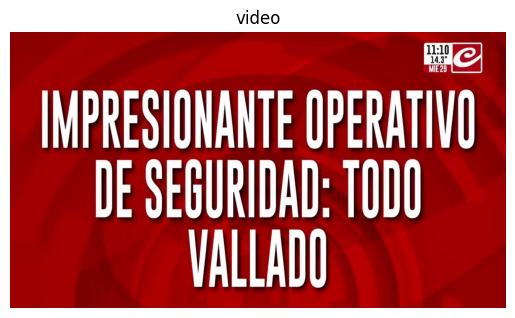

In [49]:
# Run YOLO on selected classes and crop objects
from preprocess.compute_embeddings import detect_and_crop

# First, let's check what files actually exist
print("Checking what frame files actually exist:")
actual_frame_paths = sorted(FRAMES_DIR.rglob("*.jpg"))[:10]  # Get first 10 existing files
print(f"Found {len(actual_frame_paths)} frame files:")
for i, path in enumerate(actual_frame_paths):
    print(f"  {i+1}. {path}")

cropped_objects = []

# Use the actual existing frame paths
for frame_path in actual_frame_paths:
    print(f"Processing: {frame_path}")
    
    try:
        cropped_paths = detect_and_crop(frame_path)
        
        for cropped_path in cropped_paths:
            label = cropped_path.stem.split("_")[0]  # Extract label from filename
            with Image.open(cropped_path) as cropped_img:
                cropped_objects.append((label, cropped_img.copy()))
                
        print(f"  -> Found {len(cropped_paths)} objects")
    except Exception as e:
        print(f"Error processing {frame_path}: {e}")

print(f"\nTotal cropped objects found: {len(cropped_objects)}")

# Display cropped objects
for label, cropped in cropped_objects:
    plt.figure()
    plt.title(label)
    plt.imshow(cropped)
    plt.axis("off")
    plt.show()

In [48]:
# Verify if displayed objects have paths stored in object_paths.pkl
import pickle

object_paths_file = "app/embeddings/object_paths.pkl"

# Load the object paths from the pickle file
with open(object_paths_file, "rb") as f:
    object_paths = pickle.load(f)

print("Verifying paths for displayed objects:")
for label, cropped in cropped_objects:
    found = any(label in path for path in object_paths)
    print(f"Object: {label}, Path Found: {found}")

Verifying paths for displayed objects:
Object: video, Path Found: True
Object: video, Path Found: True
Object: video, Path Found: True
Object: video, Path Found: True
Object: video, Path Found: True
Object: video, Path Found: True
Object: video, Path Found: True
Object: video, Path Found: True
Object: video, Path Found: True
Object: video, Path Found: True


In [42]:
# Examine the content of the full files object_paths.pkl and frame_paths.pkl
import pickle

object_paths_file = "app/embeddings/object_paths.pkl"
frame_paths_file = "app/embeddings/frame_paths.pkl"

# Load the object paths from the pickle file
with open(object_paths_file, "rb") as f:
    object_paths = pickle.load(f)

print("Full content of object_paths.pkl:")
for path in object_paths:
    print(path)

# Load the frame paths from the pickle file
with open(frame_paths_file, "rb") as f:
    frame_paths = pickle.load(f)

print("\nFull content of frame_paths.pkl:")
for path in frame_paths:
    print(path)

Full content of object_paths.pkl:
cropped_objects/video_1_frame_00013_obj_0.jpg
cropped_objects/video_1_frame_00014_obj_0.jpg
cropped_objects/video_1_frame_00015_obj_0.jpg
cropped_objects/video_1_frame_00016_obj_0.jpg
cropped_objects/video_1_frame_00017_obj_0.jpg
cropped_objects/video_1_frame_00018_obj_0.jpg
cropped_objects/video_1_frame_00019_obj_0.jpg
cropped_objects/video_1_frame_00020_obj_0.jpg
cropped_objects/video_1_frame_00021_obj_0.jpg
cropped_objects/video_1_frame_00004_obj_0.jpg
cropped_objects/video_1_frame_00002_obj_0.jpg
cropped_objects/video_1_frame_00003_obj_0.jpg
cropped_objects/video_1_frame_00001_obj_0.jpg
cropped_objects/video_1_frame_00005_obj_0.jpg
cropped_objects/video_1_frame_00008_obj_0.jpg
cropped_objects/video_1_frame_00006_obj_0.jpg
cropped_objects/video_1_frame_00007_obj_0.jpg
cropped_objects/video_1_frame_00009_obj_0.jpg

Full content of frame_paths.pkl:
output_frames/video_1/video_1_frame_00003.jpg
output_frames/video_1/video_1_frame_00004.jpg
output_frame

In [41]:
# Examine frame_paths and object_paths after fixing
import pickle

object_paths_file = "app/embeddings/object_paths.pkl"
frame_paths_file = "app/embeddings/frame_paths.pkl"

# Load the object paths from the pickle file
with open(object_paths_file, "rb") as f:
    object_paths = pickle.load(f)

print("Full content of object_paths.pkl:")
for path in object_paths:
    print(path)

# Load the frame paths from the pickle file
with open(frame_paths_file, "rb") as f:
    frame_paths = pickle.load(f)

print("\nFull content of frame_paths.pkl:")
for path in frame_paths:
    print(path)

print(f"\nSummary:")
print(f"Total object paths: {len(object_paths)}")
print(f"Total frame paths: {len(frame_paths)}")
print(f"Object paths start with 'cropped_objects/': {all(path.startswith('cropped_objects/') for path in object_paths)}")
print(f"Frame paths start with 'output_frames/': {all(path.startswith('output_frames/') for path in frame_paths)}")

Full content of object_paths.pkl:
cropped_objects/video_1_frame_00013_obj_0.jpg
cropped_objects/video_1_frame_00014_obj_0.jpg
cropped_objects/video_1_frame_00015_obj_0.jpg
cropped_objects/video_1_frame_00016_obj_0.jpg
cropped_objects/video_1_frame_00017_obj_0.jpg
cropped_objects/video_1_frame_00018_obj_0.jpg
cropped_objects/video_1_frame_00019_obj_0.jpg
cropped_objects/video_1_frame_00020_obj_0.jpg
cropped_objects/video_1_frame_00021_obj_0.jpg

Full content of frame_paths.pkl:
output_frames/video_1/video_1_frame_00003.jpg
output_frames/video_1/video_1_frame_00004.jpg
output_frames/video_1/video_1_frame_00002.jpg
output_frames/video_1/video_1_frame_00001.jpg
output_frames/video_1/video_1_frame_00005.jpg
output_frames/video_1/video_1_frame_00006.jpg
output_frames/video_1/video_1_frame_00007.jpg
output_frames/video_1/video_1_frame_00008.jpg
output_frames/video_1/video_1_frame_00010.jpg
output_frames/video_1/video_1_frame_00009.jpg

Summary:
Total object paths: 9
Total frame paths: 10
Obje